In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, VarianceThreshold, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 1: Load and preprocess dataset
df = pd.read_csv("Preprocessed_Dataset_For_Prediction.csv")
df = pd.get_dummies(df, drop_first=True)
X = df.drop("churn_flag", axis=1)
y = df["churn_flag"]

In [3]:
# Step 2: Remove low variance features
vt = VarianceThreshold(threshold=0.01)
X_reduced = vt.fit_transform(X)
X_columns_reduced = X.columns[vt.get_support()]
X = pd.DataFrame(X_reduced, columns=X_columns_reduced)
print(f"After variance threshold: {X.shape}")

After variance threshold: (500, 12)


In [4]:
# Step 3 (Optional): Sample dataset if large
if X.shape[0] > 10000:
    sample_idx = np.random.choice(X.index, size=5000, replace=False)
    X_sample = X.loc[sample_idx]
    y_sample = y.loc[sample_idx]
else:
    X_sample = X
    y_sample = y

In [5]:
# Step 4: Backward feature selection using SequentialFeatureSelector
print("Running backward feature selection...")
estimator = LogisticRegression(max_iter=1000)
selector = SequentialFeatureSelector(
    estimator,
    n_features_to_select=6,
    direction="backward",
    cv=3,
    n_jobs=-1
)
selector.fit(X_sample, y_sample)

selected_features = X.columns[selector.get_support()]
X_selected = X[selected_features]
print("Selected features:", list(selected_features))

Running backward feature selection...
Selected features: ['Unnamed: 0', 'mrr_amount', 'auto_renew_flag', 'usage_count', 'resolution_time_hours', 'satisfaction_score']


In [6]:
# Step 5: Train-test split and scale
def split_and_scale(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_and_scale(X_selected, y)

In [7]:
# Step 6: Evaluation function with GridSearchCV
def evaluate_model_with_tuning(model, param_grid, name):
    print(f"\n🔍 Tuning {name}...")
    grid_search = GridSearchCV(model, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Best Accuracy: {acc:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")
    
    return {
        "Model": name,
        "Accuracy": acc,
        "Best Params": grid_search.best_params_,
        "Report": classification_report(y_test, y_pred, output_dict=False),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

In [8]:
# Step 7: Define hyperparameter grids
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    },
    "SVM (Linear)": {
        "C": [0.1, 1, 10]
    },
    "SVM (RBF)": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", 0.01, 0.001]
    },
    "Naive Bayes": {
        # No params for GaussianNB
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    },
    "Decision Tree": {
        "max_depth": [3, 5, 10, None],
        "criterion": ["gini", "entropy"]
    },
    "Random Forest": {
        "n_estimators": [50, 100],
        "max_depth": [5, 10, None],
        "criterion": ["gini", "entropy"]
    }
}

In [9]:
# Step 8: Run all models
results = []

results.append(evaluate_model_with_tuning(LogisticRegression(max_iter=1000), param_grids["Logistic Regression"], "Logistic Regression"))
results.append(evaluate_model_with_tuning(SVC(kernel='linear'), param_grids["SVM (Linear)"], "SVM (Linear)"))
results.append(evaluate_model_with_tuning(SVC(kernel='rbf'), param_grids["SVM (RBF)"], "SVM (RBF)"))
results.append(evaluate_model_with_tuning(GaussianNB(), {}, "Naive Bayes"))  # No params to tune
results.append(evaluate_model_with_tuning(KNeighborsClassifier(), param_grids["KNN"], "KNN"))
results.append(evaluate_model_with_tuning(DecisionTreeClassifier(), param_grids["Decision Tree"], "Decision Tree"))
results.append(evaluate_model_with_tuning(RandomForestClassifier(), param_grids["Random Forest"], "Random Forest"))


🔍 Tuning Logistic Regression...
Logistic Regression Best Accuracy: 0.5520
Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}

🔍 Tuning SVM (Linear)...
SVM (Linear) Best Accuracy: 0.5520
Best Parameters: {'C': 0.1}

🔍 Tuning SVM (RBF)...
SVM (RBF) Best Accuracy: 0.5600
Best Parameters: {'C': 1, 'gamma': 'scale'}


C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: Undefine


🔍 Tuning Naive Bayes...
Naive Bayes Best Accuracy: 0.5680
Best Parameters: {}

🔍 Tuning KNN...
KNN Best Accuracy: 0.5520
Best Parameters: {'n_neighbors': 7, 'weights': 'uniform'}

🔍 Tuning Decision Tree...
Decision Tree Best Accuracy: 0.5760
Best Parameters: {'criterion': 'entropy', 'max_depth': 5}

🔍 Tuning Random Forest...
Random Forest Best Accuracy: 0.5680
Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}


In [10]:
# Step 9: Summarize accuracy
summary_df = pd.DataFrame({
    result["Model"]: [result["Accuracy"]] for result in results
}).T.rename(columns={0: "Accuracy"}).sort_values(by="Accuracy", ascending=False)

print("\n📊 Model Accuracy Comparison After Hyperparameter Tuning:")
print(summary_df)


📊 Model Accuracy Comparison After Hyperparameter Tuning:
                     Accuracy
Decision Tree           0.576
Naive Bayes             0.568
Random Forest           0.568
SVM (RBF)               0.560
Logistic Regression     0.552
SVM (Linear)            0.552
KNN                     0.552


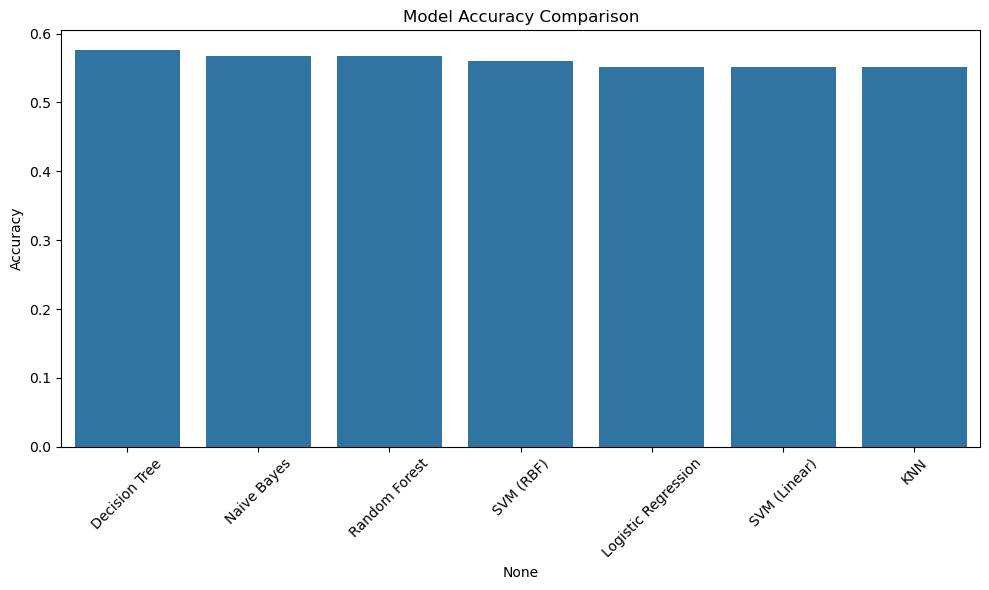

In [11]:
# Optional: Plot model performance
plt.figure(figsize=(10, 6))
sns.barplot(x=summary_df.index, y=summary_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()